In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

from helpers.prepare_validation import prepare_validation
from helpers.load_satellite_data import load_satellite_data
from helpers.background_removal import background_removal
from helpers.symmetric_balances import group_balance
from helpers.aggregate_validation_triples import aggregate_validation_triples
from helpers.xgb_tuning import tune_xgb, fit_final
from helpers.feature_selection import select_features
from helpers.prediction import predict_raster

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error
)
from sklearn.linear_model import Ridge
import seaborn as sns

In [2]:
# ──────────────────────────────
# Set dataset + feature toggles here. Everything downstream branches on this.
# ──────────────────────────────
dataset   = "kenya"          # "kenya" or "oman"
buffer    = 500
EXCLUDE_VAL_IDS = [3, 5]   # validation point ids to drop from metrics (mis-sampled; decide later)
USE_GLOBAL_BACKGROUND = False   # False: local bkg within `buffer` m | True: whole-bkg center, perturb all
RESTRICT = True
satellite = f'fused_spot_s2_{dataset}'   # base fused file; SWIR sharpened on the fly if enabled

# --- on-the-fly feature toggles (fused tiff is never regenerated) ---
SHARPEN_SWIR    = False    # pan-sharpen SWIR B11/B12 to 1.5 m using SPOT NIR

# --- auto marker/background detection from the compositional dendrogram ---
AUTO_GROUPS       = True              # True -> derive markers & natural_bgk from dendrogram clusters
if dataset == "oman":
    ACTIVE_SITES        = ["S4","S7","S10"]
    GROUP_EXCLUDE_SITES = ["S11","S12"]
    GROUP_TYPE_PREFIX   = "CORRAL"
elif dataset == "kenya":  # kenya
    ACTIVE_SITES        = ["E2", "E4","E7","E9"]   # pick your enclosure sites
    GROUP_EXCLUDE_SITES = []
    GROUP_TYPE_PREFIX   = "COR"   # matches both CORAL and CORRAL
PB_POPULATION_SPLIT = True           # detect background vs enriched populations in PB1 (GMM antimode)

# Per-dataset settings
CONFIG = {
    "kenya": {
        "natural_bgk": ['Ca', 'Cu', 'Zr', 'Ni', 'Rb', 'Si', 'Ti', 'Mg', 'Al', 'Fe'],
        "markers":     ['P', 'Zn', 'K', 'Mn', 'Sr'], 
        "has_validation": False,
        "mask_path": f'./output/baresoil_mask_{dataset}.tif',
        "fillna_type": 'None',
    },
    "oman": {
        "natural_bgk": ['Si', 'Al', 'Fe', 'Ti', 'Mg'], #Auto
        "markers":     ['P', 'K', 'Ca'],
        "has_validation": True,
        "mask_path": f'./output/baresoil_mask_{dataset}.tif',
        "fillna_type": None,
    },
}
cfg = CONFIG[dataset]
natural_bgk = cfg["natural_bgk"]
markers     = cfg["markers"]

print(f"Dataset: {dataset}  |  satellite: {satellite}")
print(f"SHARPEN_SWIR={SHARPEN_SWIR}")
print(f"Has validation set: {cfg['has_validation']}")

Dataset: kenya  |  satellite: fused_spot_s2_kenya
SHARPEN_SWIR=False
Has validation set: False


In [3]:
# Load training data
gdf = gpd.read_file(f"./data/geospatial/{dataset}_processed_closed.geojson")
if cfg["fillna_type"]:
    gdf['Type'] = gdf['Type'].fillna(cfg["fillna_type"])

# Detect markers vs natural background from the compositional dendrogram
if AUTO_GROUPS:
    from helpers.dendro_groups import compositional_groups
    _grp = compositional_groups(
        f"./data/geospatial/{dataset}_processed_closed.geojson",
        include_sites=ACTIVE_SITES, exclude_sites=GROUP_EXCLUDE_SITES,
        type_prefix=GROUP_TYPE_PREFIX,
        exclude_parts=('Res',),
        save_path=f'./output/auto_groups_{dataset}.png',
    )
    markers     = _grp['markers']
    natural_bgk = _grp['natural_bgk']
    print(f"AUTO (n={_grp['n_samples']})  markers: {markers}")
    print(f"AUTO          natural_bgk: {natural_bgk}")
    if PB_POPULATION_SPLIT:
        from helpers.pb_populations import population_split
        _pb = population_split(_grp['top_balance'],
                               save_path=f'./output/pb1_population_{dataset}.png', label='PB1')
        if _pb['bimodal']:
            print(f"  PB1 BIMODAL: antimode={_pb['threshold']:.3f} "
                  f"(background={_pb['n_low']}, enriched={_pb['n_high']})")
        else:
            print("  PB1 unimodal (single population)")
else:
    markers     = cfg["markers"]
    natural_bgk = cfg["natural_bgk"]

# Optional validation set
df_val = None
if cfg["has_validation"]:
    gdf_val = gpd.read_file("./data/geospatial/validation_processed_closed.geojson")
    # gdf_val = aggregate_validation_triples(gdf_val)
    gdf_val['Serial'] = gdf_val['Serial'].astype(str)
    gdf, gdf_val_bg, shared_elems = prepare_validation(gdf, gdf_val, restrict_training=RESTRICT)

# Background removal
gdf_removed_bgk = background_removal(gdf, buffer_distance=buffer, use_global_background=USE_GLOBAL_BACKGROUND)

if cfg["has_validation"]:
    gdf_val_removed_bgk = background_removal(gdf_val_bg, buffer_distance=buffer, use_global_background=USE_GLOBAL_BACKGROUND)
    gdf_val_removed_bgk = gdf_val_removed_bgk.loc[
        gdf_val_removed_bgk.index.intersection(gdf_val_bg['Serial'])
    ]
    df_val = gdf_val_removed_bgk.copy()

AUTO (n=56)  markers: ['Mg', 'P', 'K', 'Ca', 'Mn', 'Zn', 'Rb', 'Sr', 'Zr']
AUTO          natural_bgk: ['Al', 'Si', 'Ti', 'Fe', 'Y', 'Ba']
  PB1 BIMODAL: antimode=-1.095 (background=43, enriched=13)
✅ Background removal complete for 20 sites.


In [4]:
df = load_satellite_data(
    satellite_type=satellite, df_closed=gdf_removed_bgk,
    sharpen_swir=SHARPEN_SWIR,
)
df.head(2)

Loading raster: ./data/satellite/fused_spot_s2_kenya.tif
  aggregated 23 multi-sample pixels
  added NDVI, SAVI
  added BSI, NDMI, Clay_Index
  added NDWI, Calcite_Index
  output: 1603 rows x 37 cols (16 elements + 14 bands + 7 indices)
✅ Satellite data integration complete


,Mg,Al,Si,P,K,Ca,Ti,Mn,Fe,Zn,...,S2_B8A_nir08,S2_B11_swir16,S2_B12_swir22,NDVI,SAVI,BSI,NDMI,Clay_Index,NDWI,Calcite_Index
Serial,,,,,,,,,,,,,,,,,,,,,
1,0.053379,0.048412,0.048347,0.142755,0.078327,0.068097,0.054814,0.052232,0.054433,0.059655,...,0.294070,0.412200,0.403100,0.126301,0.092481,0.206036,-0.211040,0.977923,-0.205210,0.011162
10,0.068888,0.059536,0.060452,0.053924,0.064399,0.058069,0.066212,0.061015,0.061347,0.060917,...,0.357408,0.413578,0.406775,0.121186,0.097807,0.146413,-0.117703,0.983551,-0.204946,0.008293


In [5]:
df['balance'] = group_balance(df, markers, natural_bgk)
if df_val is not None:
    df_val['balance'] = group_balance(df_val, markers, natural_bgk)
df.head(2)

✅ Completed balance comparing between marker-elements and natural-background.


,Mg,Al,Si,P,K,Ca,Ti,Mn,Fe,Zn,...,S2_B11_swir16,S2_B12_swir22,NDVI,SAVI,BSI,NDMI,Clay_Index,NDWI,Calcite_Index,balance
Serial,,,,,,,,,,,,,,,,,,,,,
1,0.053379,0.048412,0.048347,0.142755,0.078327,0.068097,0.054814,0.052232,0.054433,0.059655,...,0.412200,0.403100,0.126301,0.092481,0.206036,-0.211040,0.977923,-0.205210,0.011162,0.492595
10,0.068888,0.059536,0.060452,0.053924,0.064399,0.058069,0.066212,0.061015,0.061347,0.060917,...,0.413578,0.406775,0.121186,0.097807,0.146413,-0.117703,0.983551,-0.204946,0.008293,0.093957


In [6]:
df['Type'] = gdf.set_index('Serial').loc[df.index, 'Type'].values

sat_keywords   = ('Band_', 'Drag_', 'S2_', 'SPOT_', 'Maxar_')
index_keywords = ('NDVI', 'SAVI', 'BSI', 'NDMI', 'NDWI', 'MSAVI',
                  'Clay', 'Calcite', 'Iron', 'EVI', 'NBR')
feature_cols = [c for c in df.columns
                if c.startswith(sat_keywords)
                or any(c.startswith(k) for k in index_keywords)]

X      = df[feature_cols].values
y      = df['balance'].values
strata = df['Type'].values
print(f"Features: {len(feature_cols)}  |  samples: {len(y)}")

Features: 21  |  samples: 1603


In [7]:
from collections import Counter

# Stratified split. Singleton Type classes (e.g. a lone 'INSIDE' sample) can't
# be stratified, so they are placed in TRAIN and the rest is stratify-split.
# This surfaces at 1.5 m because each sample gets its own pixel (no aggregation
# collapse), unlike on coarser grids.
strata = np.asarray(strata)
counts = Counter(strata)
rare_mask = np.array([counts[t] < 2 for t in strata])
if rare_mask.any():
    rare_types = sorted(set(strata[rare_mask]))
    print(f"[strata] singleton class(es) {rare_types} -> forced into TRAIN")

idx_all  = np.arange(len(y))
idx_rest = idx_all[~rare_mask]

tr, te = train_test_split(
    idx_rest, test_size=0.2, random_state=42, stratify=strata[~rare_mask],
)
idx_train = np.concatenate([tr, idx_all[rare_mask]])
idx_test  = te

X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]
print(f"[split] train={len(idx_train)}  test={len(idx_test)}")

[split] train=1282  test=321


In [8]:
print("=== Optuna round 1 (full feature set) ===")
best_params, best_iter, cv_r2 = tune_xgb(X_train, y_train, n_trials=200)
print(f"Best CV R² = {cv_r2:.3f}  |  n_estimators = {best_iter}")

model_full = fit_final(X_train, y_train, best_params, best_iter)

=== Optuna round 1 (full feature set) ===
  Trial 0: R² = 0.174 (best: 0.174)
  Trial 20: R² = 0.169 (best: 0.174)
  Trial 40: R² = 0.176 (best: 0.187)
  Trial 60: R² = 0.174 (best: 0.187)
  Trial 80: R² = 0.185 (best: 0.187)
  Trial 100: R² = 0.197 (best: 0.197)
  Trial 120: R² = 0.169 (best: 0.197)
  Trial 140: R² = 0.172 (best: 0.198)
  Trial 160: R² = 0.191 (best: 0.198)
  Trial 180: R² = 0.183 (best: 0.200)
Best CV R² = 0.200  |  n_estimators = 34


In [9]:
# Permutation importances (report only). No feature reduction: round-2
# retuning on reduced features did not beat round 1, so we keep all features.
kept_feats, importances = select_features(
    model_full, X_test, y_test, feature_cols, keep_frac=0.8,
)
print("\nAll feature importances:")
print(importances.round(4).to_string())

Permutation importance: 19 / 21 features have positive contribution
Keeping top 16 (keep_frac=0.8)
S2_B8A_nir08      0.0392
S2_B11_swir16     0.0341
NDMI              0.0333
Clay_Index        0.0281
SPOT_red          0.0232
S2_B12_swir22     0.0187
SPOT_green        0.0174
NDWI              0.0168
S2_B2_blue        0.0122
SPOT_blue         0.0112
S2_B4_red         0.0071
S2_B7_rededge3    0.0044
SPOT_nir          0.0037
S2_B5_rededge1    0.0035
SAVI              0.0020
dtype: float64

All feature importances:
S2_B8A_nir08      0.0392
S2_B11_swir16     0.0341
NDMI              0.0333
Clay_Index        0.0281
SPOT_red          0.0232
S2_B12_swir22     0.0187
SPOT_green        0.0174
NDWI              0.0168
S2_B2_blue        0.0122
SPOT_blue         0.0112
S2_B4_red         0.0071
S2_B7_rededge3    0.0044
SPOT_nir          0.0037
S2_B5_rededge1    0.0035
SAVI              0.0020
S2_B8_nir         0.0018
S2_B3_green       0.0014
Calcite_Index     0.0011
S2_B6_rededge2    0.0005
NDVI      

In [10]:
model_eval = fit_final(X_train, y_train, best_params, best_iter)

def regression_metrics(y, yhat):
    return dict(
        R2=r2_score(y, yhat),
        RMSE=np.sqrt(mean_squared_error(y, yhat)),
        MAE=mean_absolute_error(y, yhat),
        MAPE=mean_absolute_percentage_error(y, yhat),
    )

ridge = Ridge(alpha=1.0, random_state=42).fit(X_train, y_train)
print("\nInternal 20% test:")
print(f"  Ridge   : {regression_metrics(y_test, ridge.predict(X_test))}")
print(f"  XGBoost : {regression_metrics(y_test, model_eval.predict(X_test))}")

X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])
model = fit_final(X_all, y_all, best_params, best_iter)
print(f"\nFinal model refit on full data: {len(y_all)} samples")


Internal 20% test:
  Ridge   : {'R2': 0.0324681353625933, 'RMSE': np.float64(0.333656516822738), 'MAE': 0.16073639207520196, 'MAPE': 5.0031493424376245}
  XGBoost : {'R2': 0.06992292187204452, 'RMSE': np.float64(0.3271345723860994), 'MAE': 0.14416233342201257, 'MAPE': 3.3232485060551302}

Final model refit on full data: 1603 samples


/Users/antonkout/miniforge3/envs/camp-geomatics/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.78317e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [11]:
# Predict, keeping ONLY bare-soil pixels (mask=1). Same SWIR setting as training.
prediction_path = predict_raster(
    model=model, satellite=satellite, feature_cols=feature_cols,
    mask_path=cfg['mask_path'], mask_keep_value=1,
    sharpen_swir=SHARPEN_SWIR,
    output_path=f"./output/{satellite}_balance_prediction.tif"
)

Model expects 21 features
Raster: 14 bands, 1836x1928
  added NDVI, SAVI
  added BSI, NDMI, Clay_Index
  added NDWI, Calcite_Index
Feature matrix: (3539808, 21), expected 21
  predicted: 3,539,808 pixels (100.0%)
  mask applied: kept 2,001,898 / 3,539,808 (56.6%)
Saved → ./output/fused_spot_s2_kenya_balance_prediction.tif


In [12]:
if cfg["has_validation"]:
    # External validation: sample predicted raster at validation points
    with rasterio.open(prediction_path) as src:
        pts = df_val.to_crs(src.crs)
        coords = [(p.x, p.y) for p in pts.geometry]
        sampled = np.array([v[0] for v in src.sample(coords)], dtype=np.float32)

    df_eval = pd.DataFrame({
        'true':      df_val['balance'].values,
        'predicted': sampled,
    })
    df_eval = df_eval.replace([np.inf, -np.inf], np.nan).dropna()
    df_eval['residual'] = df_eval['predicted'] - df_eval['true']
    if EXCLUDE_VAL_IDS:
        drop = [i for i in EXCLUDE_VAL_IDS if i in df_eval.index]
        if drop:
            print(f"  excluding validation ids {drop} from metrics (mis-sampled)")
            df_eval = df_eval.drop(index=drop)
    eval_label = 'External validation'
else:
    # Internal 20% test split
    y_pred_internal = model_eval.predict(X_test)
    df_eval = pd.DataFrame({
        'true':      y_test,
        'predicted': y_pred_internal,
        'residual':  y_pred_internal - y_test,
    }).reset_index(drop=True)
    eval_label = 'Internal 20% test'

print(f"{eval_label}: n = {len(df_eval)}")
df_eval.head()

Internal 20% test: n = 321


,true,predicted,residual
0,0.086391,0.028268,-0.058122
1,-0.138459,0.002886,0.141345
2,0.016417,0.004733,-0.011683
3,1.707318,0.145418,-1.561901
4,-0.001613,0.117665,0.119279


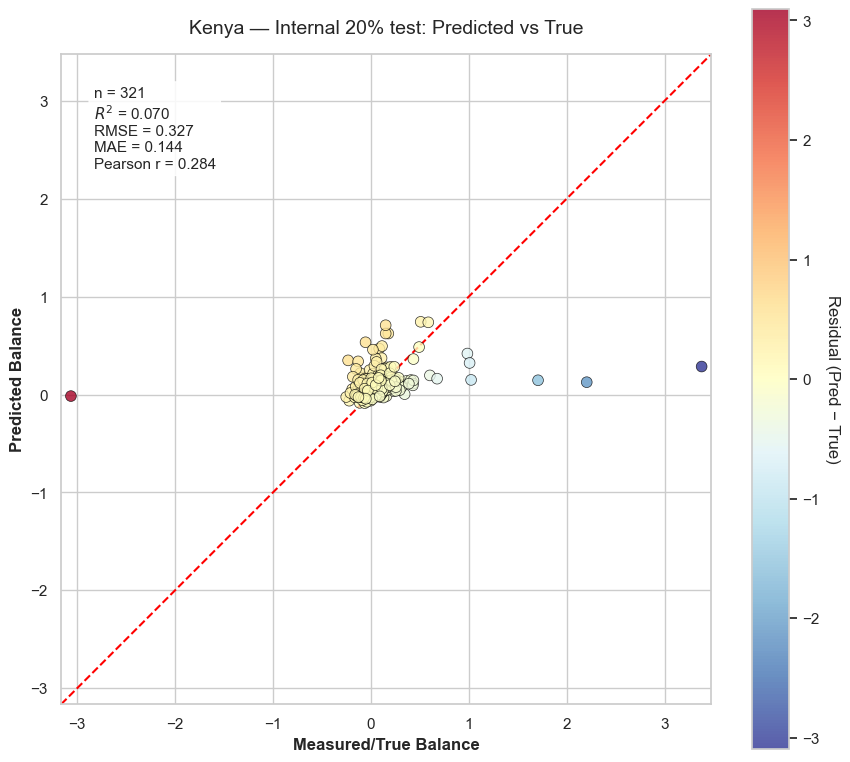

In [13]:
y_true    = df_eval['true'].values
y_pred    = df_eval['predicted'].values
residuals = df_eval['residual'].values

r2      = r2_score(y_true, y_pred)
rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
mae     = mean_absolute_error(y_true, y_pred)
pearson = np.corrcoef(y_true, y_pred)[0, 1]

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 8))

vmax = max(abs(residuals.min()), abs(residuals.max()))
sc = ax.scatter(y_true, y_pred, c=residuals, cmap='RdYlBu_r',
                vmin=-vmax, vmax=vmax,
                s=60, alpha=0.8, edgecolor='black', linewidth=0.5, zorder=3)

cbar = plt.colorbar(sc)
cbar.set_label('Residual (Pred − True)', rotation=270, labelpad=15)

# Point labels only for small validation sets
if len(df_eval) <= 80:
    for idx, row in df_eval.iterrows():
        ax.text(row['true'] + 0.015, row['predicted'] + 0.015,
                str(idx), fontsize=8, alpha=0.8, zorder=4)

lims = [min(y_true.min(), y_pred.min()) - 0.1,
        max(y_true.max(), y_pred.max()) + 0.1]
ax.plot(lims, lims, color='red', linestyle='--', lw=1.5,
        label='Ideal (1:1)', zorder=2)

stats_text = (f'n = {len(df_eval)}\n'
              f'$R^2$ = {r2:.3f}\n'
              f'RMSE = {rmse:.3f}\n'
              f'MAE = {mae:.3f}\n'
              f'Pearson r = {pearson:.3f}')
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

ax.set_xlabel('Measured/True Balance', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Balance', fontsize=12, fontweight='bold')
ax.set_title(f'{dataset.title()} — {eval_label}: Predicted vs True',
             fontsize=14, pad=15)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()